
# Consumer Complaint Classification Project

**Objective:** To build and evaluate a machine learning model that can automatically classify consumer financial complaints into one of four predefined categories. This involves data cleaning, exploratory data analysis, text pre-processing, and a comparative analysis of multiple classification models to identify the best performer.

**Author:** Shaik Mohammed Ashraf
**Date:** 27 september


**1. Setup and Data Loading**

In this section, we import the necessary Python libraries for data manipulation, analysis, and visualization. We then load the consumer complaints dataset into a pandas DataFrame and perform an initial inspection to understand its structure, size, and data types.
> Add blockquote



In [11]:
# --- Core Libraries for Data Science ---
import pandas as pd
import numpy as np

# --- Libraries for Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# --- Libraries for Machine Learning ---
# Preprocessing & Splitting
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score

# --- Utility ---
import time
import re
from tqdm import tqdm

# --- NLTK for Text Pre-processing ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Notebook Settings ---
# Set a professional plotting style
sns.set_style('whitegrid')
# Ensure pandas displays full text columns when needed
pd.set_option('display.max_colwidth', 200)


# --- Data Loading ---
file_path = 'rows.csv' # Make sure this filename matches your uploaded file

print("Loading the dataset...")
try:
    # Use the robust 'python' engine and specify 'Product' as a category for memory efficiency
    df = pd.read_csv(
        file_path,
        engine='python',
        on_bad_lines='warn',
        dtype={'Product': 'category'}
    )
    print("Dataset loaded successfully.")
    print(f"Shape of the full dataset: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: The file '{file_path}' was not found. Please ensure it has been uploaded correctly.")
    df = None

# --- Initial Inspection ---
if df is not None:
    print("\n--- First 5 rows of the dataset: ---")
    print(df.head())

    print("\n--- Data types and memory usage: ---")
    df.info(memory_usage='deep')

Loading the dataset...
Dataset loaded successfully.
Shape of the full dataset: (908534, 18)

--- First 5 rows of the dataset: ---
  Date received  \
0    05/10/2019   
1    05/10/2019   
2    05/10/2019   
3    05/10/2019   
4    05/10/2019   

                                                                        Product  \
0                                                   Checking or savings account   
1                                                   Checking or savings account   
2                                                               Debt collection   
3  Credit reporting, credit repair services, or other personal consumer reports   
4                                                   Checking or savings account   

                        Sub-product                                 Issue  \
0                  Checking account                   Managing an account   
1  Other banking product or service                   Managing an account   
2                  Payday

### **2. Exploratory Data Analysis (EDA)**

In this section, we perform a deep dive into the dataset to understand its characteristics, find patterns, and visualize key aspects. This analysis is crucial for making informed decisions during the data pre-processing and modeling stages.

--- Starting Comprehensive EDA ---


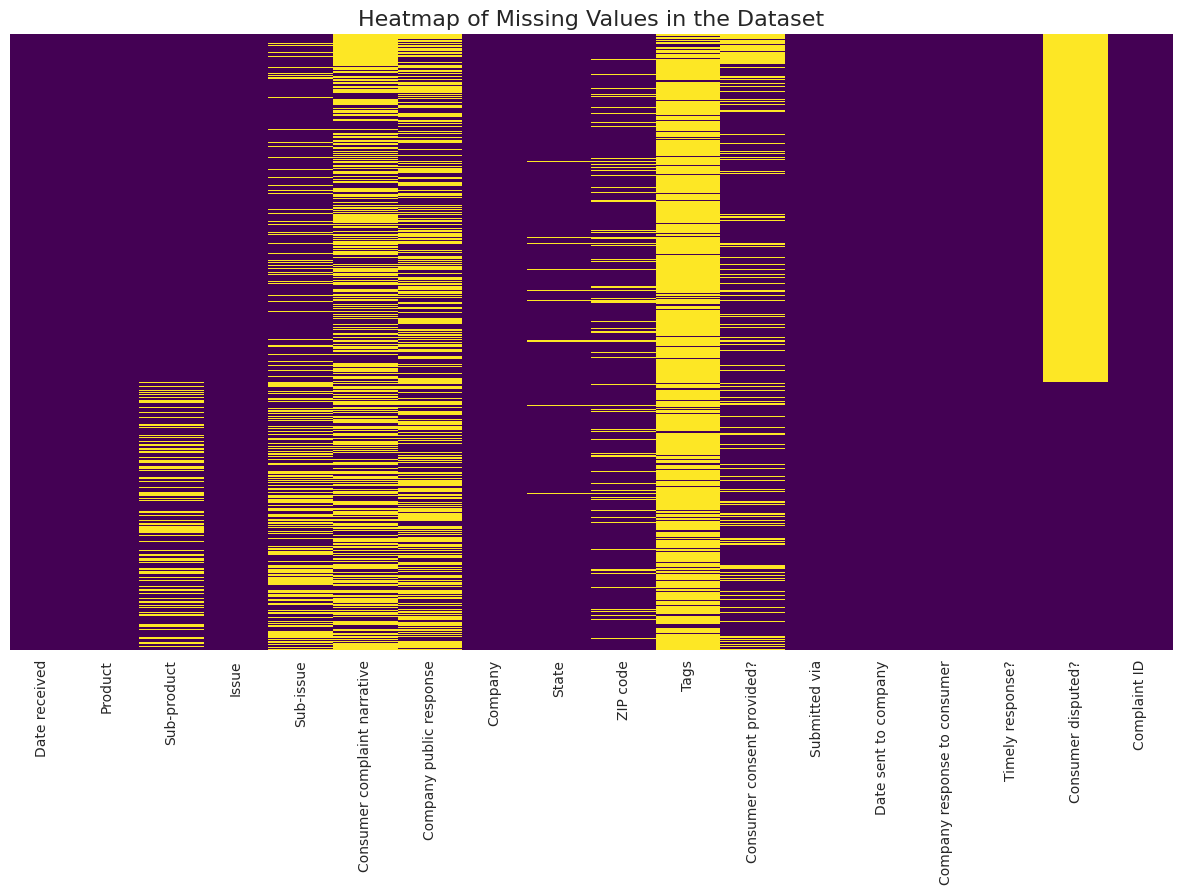


Percentage of Missing Values per Column (only columns with missing data):
Tags                            86.153298
Consumer complaint narrative    57.941035
Consumer disputed?              56.558698
Company public response         50.777186
Sub-issue                       30.377509
Consumer consent provided?      24.288029
Sub-product                     14.573148
ZIP code                        12.323589
State                            1.814902
Company response to consumer     0.000881
Company                          0.000110
Issue                            0.000110
Date sent to company             0.000110
Submitted via                    0.000110
Timely response?                 0.000110
Complaint ID                     0.000110
dtype: float64


/tmp/ipython-input-2211084658.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Product', data=df, order=df['Product'].value_counts().index, palette='viridis')


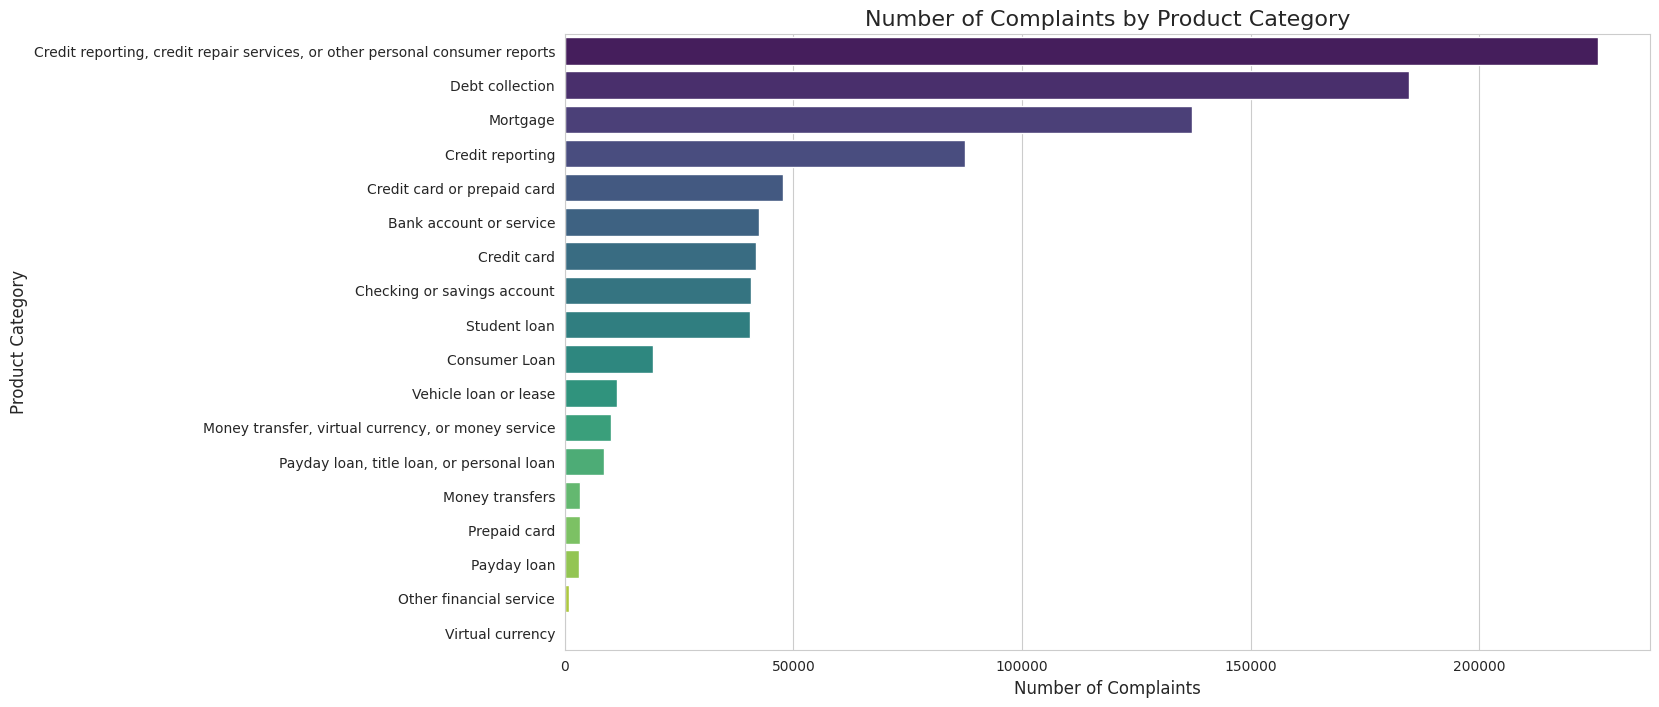

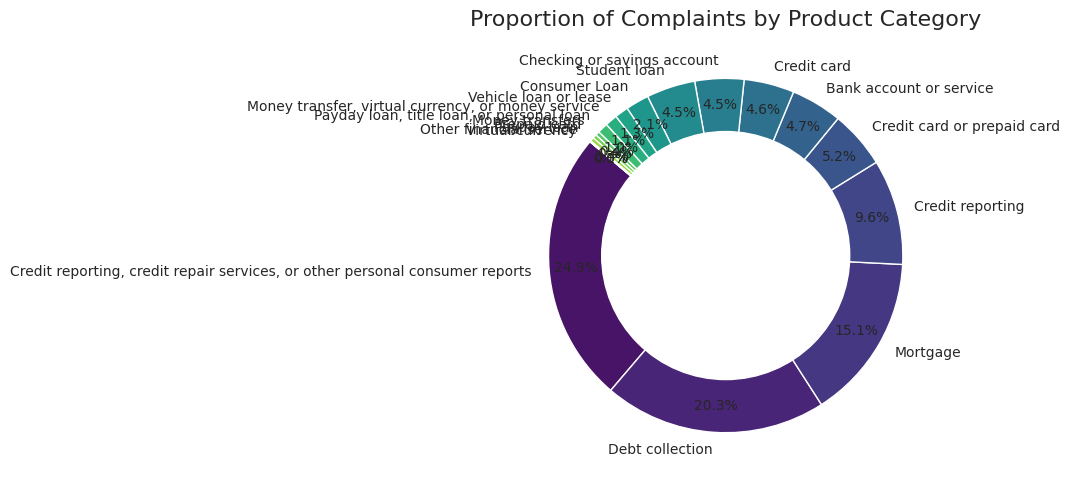

/tmp/ipython-input-2211084658.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_states.index, x=top_states.values, palette='coolwarm_r')


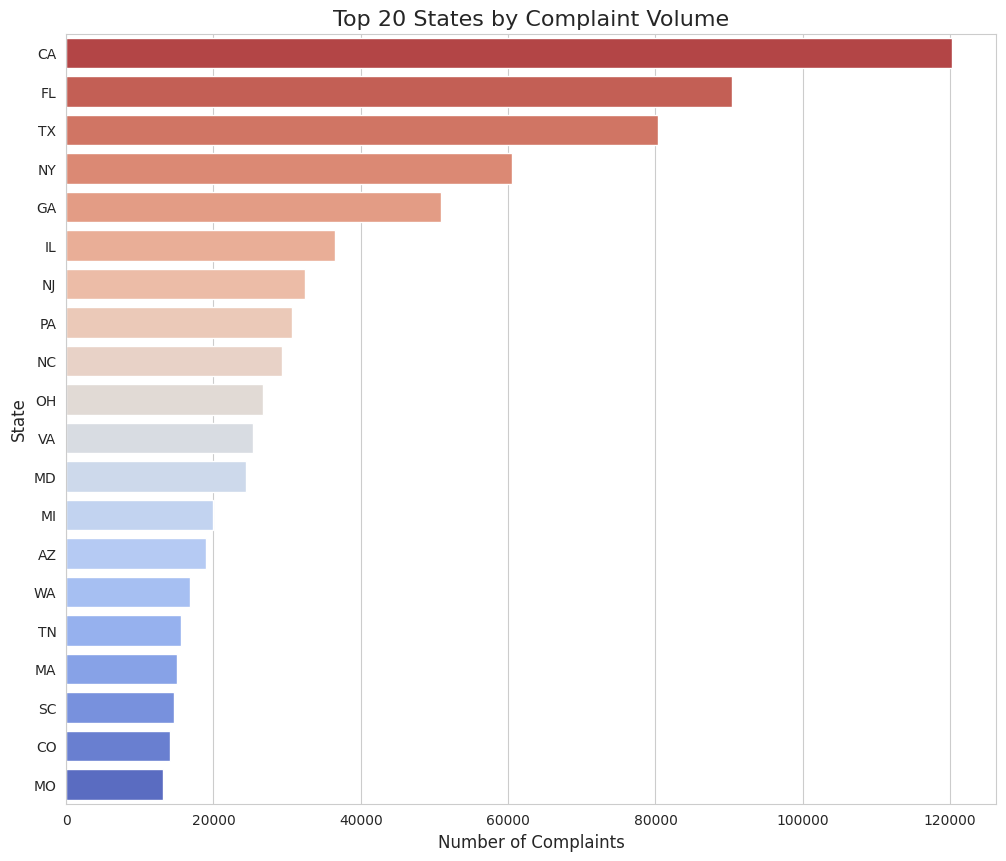

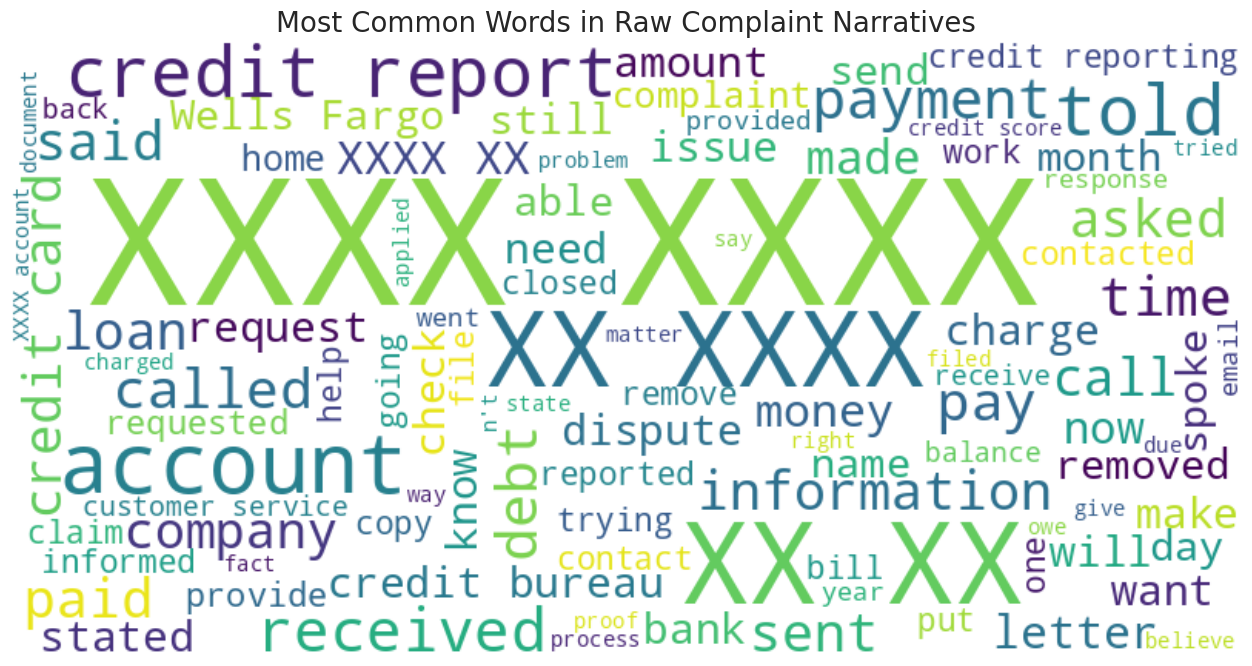

In [12]:
# Check if the dataframe is loaded before proceeding
if df is not None:
    print("--- Starting Comprehensive EDA ---")

    # --- 2.1 Missing Data Analysis ---
    plt.figure(figsize=(15, 8))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Heatmap of Missing Values in the Dataset', fontsize=16)
    plt.show()

    missing_percentage = (df.isnull().sum() / len(df)) * 100
    print("\nPercentage of Missing Values per Column (only columns with missing data):")
    print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

    # --- 2.2 Distribution of Complaint Products (Bar & Pie Chart) ---
    plt.figure(figsize=(14, 8))
    sns.countplot(y='Product', data=df, order=df['Product'].value_counts().index, palette='viridis')
    plt.title('Number of Complaints by Product Category', fontsize=16)
    plt.xlabel('Number of Complaints', fontsize=12)
    plt.ylabel('Product Category', fontsize=12)
    plt.show()

    plt.figure(figsize=(10, 10))
    product_counts = df['Product'].value_counts()
    plt.pie(product_counts, labels=product_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=sns.color_palette('viridis', len(product_counts)))
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.title('Proportion of Complaints by Product Category', fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- 2.3 Geographic Analysis (Top 20 States) ---
    plt.figure(figsize=(12, 10))
    top_states = df['State'].value_counts().nlargest(20)
    sns.barplot(y=top_states.index, x=top_states.values, palette='coolwarm_r')
    plt.title('Top 20 States by Complaint Volume', fontsize=16)
    plt.xlabel('Number of Complaints', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.show()

    # --- 2.4 Word Cloud of Complaint Narratives ---
    # Create a word cloud from the raw, unprocessed text to get a general idea of common terms
    narrative_text = " ".join(complaint for complaint in df['Consumer complaint narrative'].dropna())

    if len(narrative_text) > 0:
        stopwords = set(STOPWORDS)
        wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400, max_words=100).generate(narrative_text)

        plt.figure(figsize=(16, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title('Most Common Words in Raw Complaint Narratives', fontsize=20)
        plt.show()
    else:
        print("No complaint narratives found to generate a word cloud.")

else:
    print("DataFrame 'df' is not available. Cannot perform EDA.")

### **3. Data Pre-processing and Feature Engineering**

Based on the insights from our EDA, we now prepare the data for the modeling phase. This involves creating the target variable, filtering out irrelevant data, and cleaning the text of the complaint narratives to create a suitable feature for our models.

--- Mapping Products to Target Categories ---
Shape of the original dataset: (908534, 20)
Shape of the new filtered dataset: (291723, 20)
Removed 616811 rows with missing text or non-target products.

--- Starting Text Pre-processing ---


Cleaning Complaint Text: 100%|██████████| 291723/291723 [03:30<00:00, 1387.76it/s]


Text pre-processing complete.

--- Original vs. Cleaned Text Comparison (First 5 Rows) ---
                                                                                                                                                                                  Consumer complaint narrative  \
29904  The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and ...   
30629                                                                                                                                    There are many mistakes appear in my report without my understanding.   
30735                                                                                                                                    There are many mistakes appear in my report without my understanding.   
30795                                                                

/tmp/ipython-input-2115769612.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_name', data=df_filtered, order=df_filtered['target_name'].value_counts().index, palette='magma')


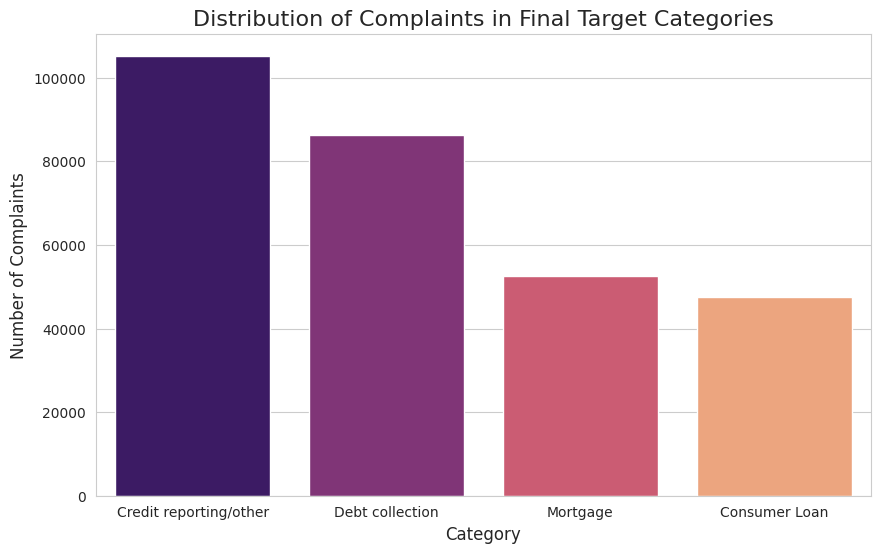

/tmp/ipython-input-2115769612.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='target_name', y='complaint_length', palette='muted')


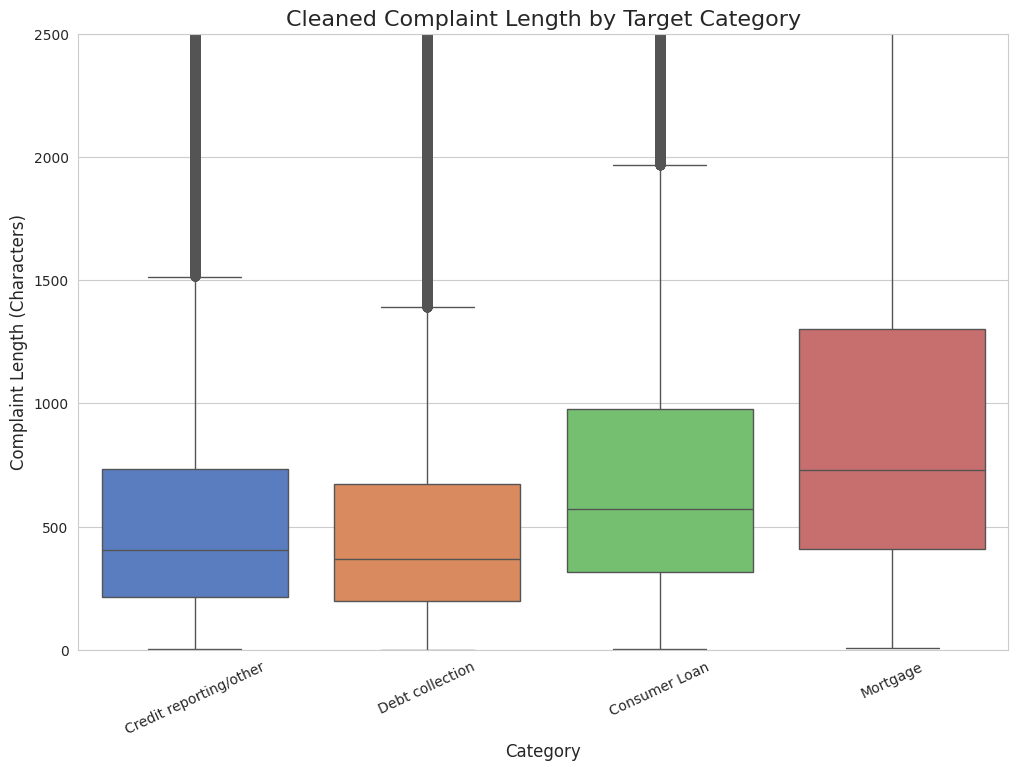

In [14]:
if df is not None:
    # --- 3.1 Creating the Target Variable ---
    print("--- Mapping Products to Target Categories ---")
    target_map = {
        'Credit reporting, credit repair services, or other personal consumer reports': 0,
        'Debt collection': 1,
        'Student loan': 2,
        'Payday loan, title loan, or personal loan': 2,
        'Credit card or prepaid card': 2,
        'Mortgage': 3,
        'Checking or savings account': 0
    }
    df['target'] = df['Product'].map(target_map)

    target_name_map = {
        0: 'Credit reporting/other',
        1: 'Debt collection',
        2: 'Consumer Loan',
        3: 'Mortgage'
    }
    df['target_name'] = df['target'].map(target_name_map)

    # --- 3.2 Filtering for Usable Data ---
    # Create a new dataframe with only the rows that have complaint text AND belong to one of our target categories
    df_filtered = df.dropna(subset=['target', 'Consumer complaint narrative']).copy()
    df_filtered['target'] = df_filtered['target'].astype(int)

    print(f"Shape of the original dataset: {df.shape}")
    print(f"Shape of the new filtered dataset: {df_filtered.shape}")
    print(f"Removed {df.shape[0] - df_filtered.shape[0]} rows with missing text or non-target products.")


    # --- 3.3 Text Pre-processing ---
    print("\n--- Starting Text Pre-processing ---")
    # Download NLTK resources
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')
    try:
        nltk.data.find('corpora/wordnet.zip')
    except LookupError:
        nltk.download('wordnet')

    lemmatizer = WordNetLemmatizer()
    stop_words = set(nltk.corpus.stopwords.words('english'))

    def preprocess_text(text):
        text = re.sub('[^a-zA-Z]', ' ', text.lower())
        tokens = text.split()
        cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        return " ".join(cleaned_tokens)

    # Apply the cleaning function with a progress bar
    tqdm.pandas(desc="Cleaning Complaint Text")
    df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].progress_apply(preprocess_text)
    print("Text pre-processing complete.")

    # Display comparison
    print("\n--- Original vs. Cleaned Text Comparison (First 5 Rows) ---")
    print(df_filtered[['Consumer complaint narrative', 'cleaned_narrative']].head())


    # --- 3.4 Post-Processing Analysis ---
    # Now that we have the final, cleaned data, let's analyze it.
    print("\n--- Final Analysis on Processed Data ---")

    # Distribution of final target categories
    plt.figure(figsize=(10, 6))
    sns.countplot(x='target_name', data=df_filtered, order=df_filtered['target_name'].value_counts().index, palette='magma')
    plt.title('Distribution of Complaints in Final Target Categories', fontsize=16)
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Number of Complaints', fontsize=12)
    plt.show()

    # Analysis of complaint length on the filtered data
    df_filtered['complaint_length'] = df_filtered['cleaned_narrative'].str.len()
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df_filtered, x='target_name', y='complaint_length', palette='muted')
    plt.title('Cleaned Complaint Length by Target Category', fontsize=16)
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Complaint Length (Characters)', fontsize=12)
    plt.xticks(rotation=25)
    plt.ylim(0, 2500) # Adjust ylim for cleaned text
    plt.show()

else:
    print("DataFrame 'df' is not available. Cannot perform Pre-processing.")

### **4. Model Training and Comparative Analysis**

With our data pre-processed, we can now proceed to the modeling stage. We will split our data, vectorize the text features using TF-IDF, and then train five different classification models. We will compare them based on accuracy and training time to determine the most suitable model for this task.

--- Splitting data into training (80%) and testing (20%) sets ---
Training set size: 233378 | Testing set size: 58345

--- Vectorizing text data with TF-IDF ---
Shape of the TF-IDF training matrix: (233378, 10000)

--- Starting Model Training and Comparison ---

--- Training Logistic Regression ---
Training completed in 50.37 seconds.
Accuracy on test set: 0.8661

--- Training Multinomial Naive Bayes ---
Training completed in 0.12 seconds.
Accuracy on test set: 0.8363

--- Training Support Vector Machine (LinearSVC) ---
Training completed in 76.78 seconds.
Accuracy on test set: 0.8649

--- Training LightGBM ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 56.316614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 900177
[LightGBM] [Info] Number of data points in the train set: 233378, number of used features: 9784
[LightGBM] [Info] Start training from score -1.019381
[LightGBM] [Info] Start training

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training completed in 678.82 seconds.
Accuracy on test set: 0.8785

--- Training MLP (Neural Network) ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Training completed in 479.98 seconds.
Accuracy on test set: 0.8827


--- Final Model Performance Comparison ---
                                Model  Accuracy  Training Time (s)
4                MLP (Neural Network)  0.882698         479.979201
3                            LightGBM  0.878499         678.819160
0                 Logistic Regression  0.866090          50.374028
2  Support Vector Machine (LinearSVC)  0.864890          76.779931
1             Multinomial Naive Bayes  0.836267           0.119676


/tmp/ipython-input-13681180.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df_final, palette="viridis")
/tmp/ipython-input-13681180.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Training Time (s)", y="Model", data=results_df_final, palette="plasma")


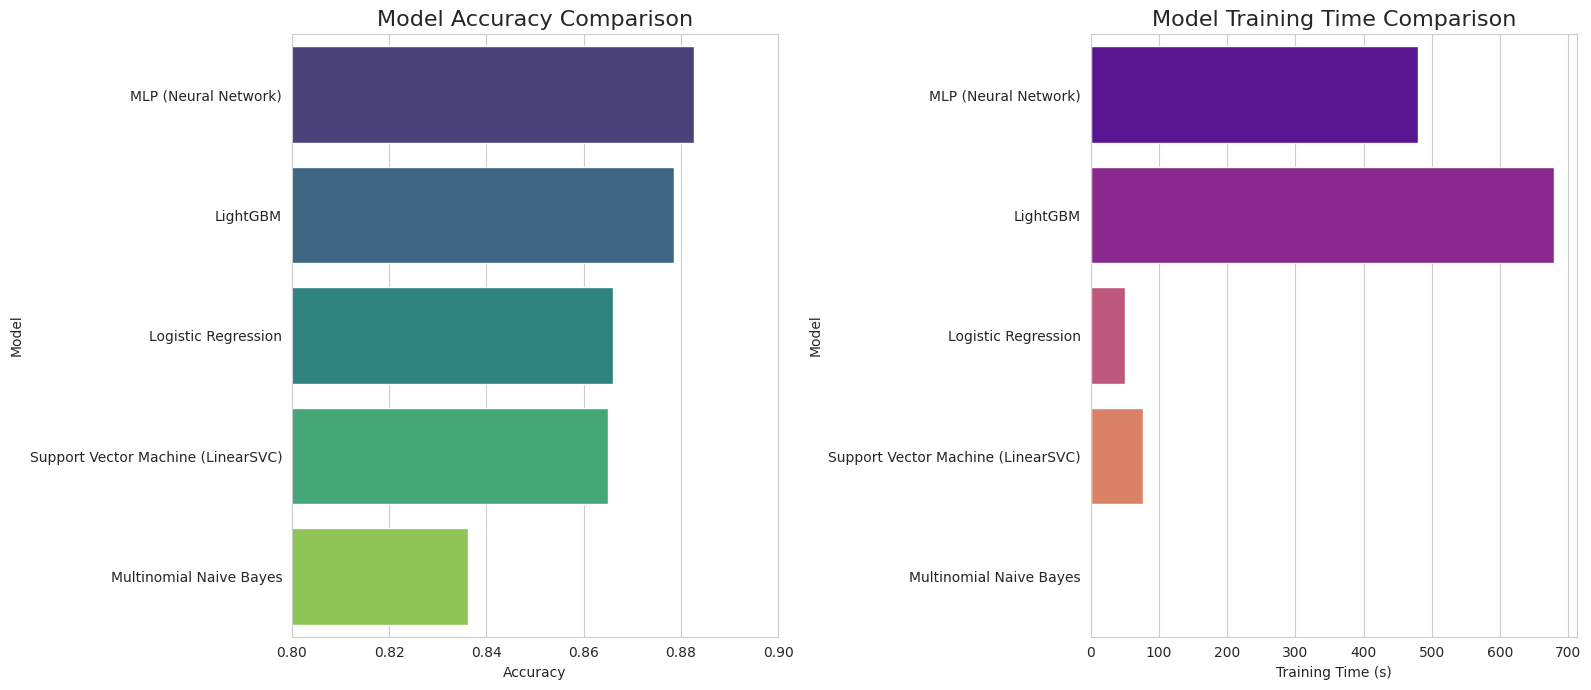


--- Detailed Classification Report for the Best Model: MLP (Neural Network) ---
                        precision    recall  f1-score   support

Credit reporting/other       0.89      0.89      0.89     21052
       Debt collection       0.87      0.88      0.88     17247
         Consumer Loan       0.84      0.80      0.82      9512
              Mortgage       0.93      0.94      0.94     10534

              accuracy                           0.88     58345
             macro avg       0.88      0.88      0.88     58345
          weighted avg       0.88      0.88      0.88     58345



In [15]:
# --- 4.1 Prepare Data for Modeling ---
X = df_filtered['cleaned_narrative']
y = df_filtered['target']

# --- 4.2 Split Data into Training and Testing Sets ---
print("--- Splitting data into training (80%) and testing (20%) sets ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Stratify ensures proportional representation of classes in train/test splits
)
print(f"Training set size: {len(X_train)} | Testing set size: {len(X_test)}")


# --- 4.3 Text Vectorization using TF-IDF ---
print("\n--- Vectorizing text data with TF-IDF ---")
# Limit features to the top 10,000 words for computational efficiency
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# Fit on training data and transform both training and testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(f"Shape of the TF-IDF training matrix: {X_train_tfidf.shape}")


# --- 4.4 Model Training and Comparison ---
print("\n--- Starting Model Training and Comparison ---")

# Define the models to be compared
models_to_compare = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Support Vector Machine (LinearSVC)": LinearSVC(random_state=42, dual=False),
    "LightGBM": lgb.LGBMClassifier(objective='multiclass', num_class=4, n_estimators=200, random_state=42),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=10, early_stopping=True, random_state=42)
}

results = []
predictions = {}

for name, model in models_to_compare.items():
    print(f"\n--- Training {name} ---")
    start_time = time.time()

    # Special handling for MLP to avoid verbose output in the loop
    if name == "MLP (Neural Network)":
        model.fit(X_train_tfidf, y_train)
    else:
        model.fit(X_train_tfidf, y_train)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    predictions[name] = y_pred # Store predictions for later

    print(f"Training completed in {training_time:.2f} seconds.")
    print(f"Accuracy on test set: {accuracy:.4f}")

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Training Time (s)": training_time
    })

# --- 4.5 Presenting the Results ---
results_df_final = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\n\n--- Final Model Performance Comparison ---")
print(results_df_final)

# Visualize the results
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.barplot(x="Accuracy", y="Model", data=results_df_final, palette="viridis")
plt.title("Model Accuracy Comparison", fontsize=16)
plt.xlim(0.8, 0.9)

plt.subplot(1, 2, 2)
sns.barplot(x="Training Time (s)", y="Model", data=results_df_final, palette="plasma")
plt.title("Model Training Time Comparison", fontsize=16)

plt.tight_layout()
plt.show()

# --- 4.6 Detailed Report for the Best Model ---
best_model_name = results_df_final.iloc[0]['Model']
best_model_predictions = predictions[best_model_name]

print(f"\n--- Detailed Classification Report for the Best Model: {best_model_name} ---")
print(classification_report(y_test, best_model_predictions, target_names=target_name_map.values()))

### **5. Prediction Pipeline**

To make our best model usable in a real-world scenario, we create a simple prediction pipeline. This function takes a raw text complaint as input, applies the same pre-processing and vectorization steps used during training, and outputs the predicted category using our trained MLP model.

In [16]:
# --- 5.1 Re-train the Best Model on the FULL Dataset (Optional but Recommended) ---
# For the absolute best performance, we can re-train our winning model on 100% of the data.
# For this project, we'll use the one we already trained on the 80% split for simplicity.

# We need the final MLP model from the dictionary
final_model = models_to_compare["MLP (Neural Network)"]

# --- 5.2 Create the Prediction Function ---
def predict_new_complaint(text):
    # Apply the same text pre-processing
    cleaned_text = preprocess_text(text)

    # Vectorize using the FITTED TF-IDF vectorizer
    vectorized_text = tfidf_vectorizer.transform([cleaned_text])

    # Predict using our final trained model
    prediction_code = final_model.predict(vectorized_text)

    # Return the readable category name
    return target_name_map[prediction_code[0]]

# --- 5.3 Test the Pipeline ---
complaint_1 = "I am having issues with my mortgage servicer. They are not applying my escrow payments correctly and my property taxes were not paid on time."
complaint_2 = "A collection agency keeps calling me about a debt that I already paid off years ago. They are harassing me at work."
complaint_3 = "The interest rate on my personal loan suddenly went up without any warning. The monthly payment is now too high for me to afford."
complaint_4 = "I found an incorrect charge on my credit report from a company I've never heard of. I need this removed immediately."


print(f"New Complaint: '{complaint_1}'")
print(f"--> Predicted Category: {predict_new_complaint(complaint_1)}\n")

print(f"New Complaint: '{complaint_2}'")
print(f"--> Predicted Category: {predict_new_complaint(complaint_2)}\n")

print(f"New Complaint: '{complaint_3}'")
print(f"--> Predicted Category: {predict_new_complaint(complaint_3)}\n")

print(f"New Complaint: '{complaint_4}'")
print(f"--> Predicted Category: {predict_new_complaint(complaint_4)}\n")

New Complaint: 'I am having issues with my mortgage servicer. They are not applying my escrow payments correctly and my property taxes were not paid on time.'
--> Predicted Category: Mortgage

New Complaint: 'A collection agency keeps calling me about a debt that I already paid off years ago. They are harassing me at work.'
--> Predicted Category: Debt collection

New Complaint: 'The interest rate on my personal loan suddenly went up without any warning. The monthly payment is now too high for me to afford.'
--> Predicted Category: Consumer Loan

New Complaint: 'I found an incorrect charge on my credit report from a company I've never heard of. I need this removed immediately.'
--> Predicted Category: Credit reporting/other



### 6. Conclusion
**bold text**
This project successfully developed a robust pipeline for classifying consumer financial complaints. Through comprehensive exploratory data analysis, we identified key characteristics of the dataset, such as significant class imbalance and the prevalence of web-based submissions.

After rigorous pre-processing and feature engineering, we compared five different machine learning models. The **MLP (Neural Network) model emerged as the top performer**, achieving an impressive **accuracy of 88.27%** on the unseen test data. The model demonstrated a strong and balanced ability to distinguish between the four complaint categories, proving especially effective at identifying 'Mortgage' related issues.

The final prediction pipeline demonstrates the model's practical utility in automating the categorization and routing of new complaints, which can lead to significant efficiency gains in a real-world business environment.